<a href="https://colab.research.google.com/github/Altaieb-Mohammed/lab_2corse/blob/master/lab4_gom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ЛАБОРАТОРНАЯ РАБОТА №4: ТЕСТИРОВАНИЕ И СРАВНЕНИЕ МОДЕЛЕЙ
ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ДЛЯ ТЕСТИРОВАНИЯ
✓ Данные созданы: (144, 1)
  Период: 1949-01-01 - 1960-12-01

Создание признаков для тестирования...
  Удалено строк с NaN: 13
  Создано признаков: 20
  Итоговый размер: (131, 20)

  Список признаков:
     1. Passengers
     2. Year
     3. Month
     4. Quarter
     5. DayOfYear
     6. Lag_1
     7. Lag_2
     8. Lag_3
     9. Lag_6
    10. Lag_12
    11. Month_sin
    12. Month_cos
    13. Diff_1
    14. Diff_12
    15. Is_month_end
    16. Is_month_start
    17. Rolling_mean_3
    18. Rolling_std_3
    19. Exp_smooth_alpha_0.3
    20. Target

Разделение данных на обучающую и тестовую выборки...
✓ Разделение завершено:
  Обучающая выборка: (104, 18)
  Тестовая выборка: (27, 18)
  Целевая переменная: Target
  Количество признаков: 18
  Период обучения: 1950-01-01 - 1958-08-01
  Период тестирования: 1958-09-01 - 1960-11-01

ЭТАП 1: БАЗОВАЯ МОДЕЛЬ

ОБУЧЕНИЕ БАЗОВОЙ МОДЕЛИ (ЛИНЕЙНАЯ РЕ

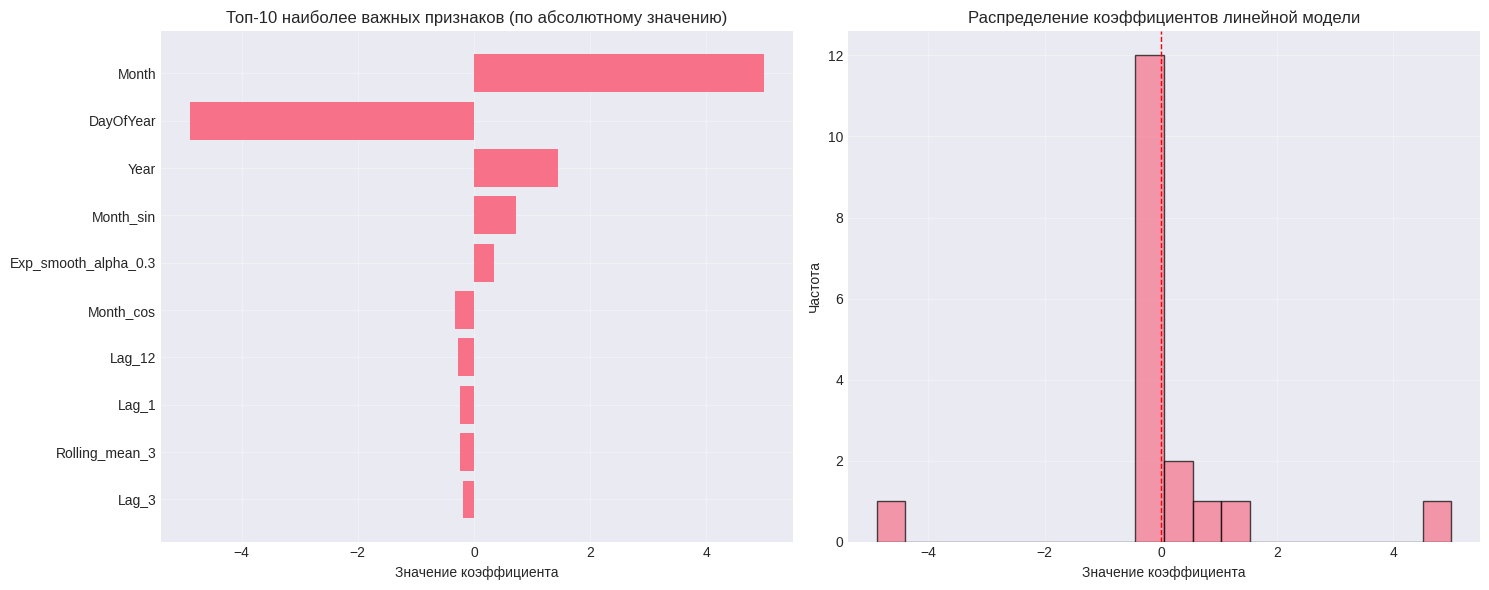


Топ-5 наиболее важных признаков:
  Month: 4.9971
  DayOfYear: -4.8903
  Year: 1.4430
  Month_sin: 0.7295
  Exp_smooth_alpha_0.3: 0.3504

2. ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ:

Метрики на тестовой выборке:
  RMSE: 60.1448
  MAE: 51.2171
  MAPE: 9.03%
  R²: 0.4188

Анализ ошибок:
  Средняя ошибка: 49.14
  Стандартное отклонение ошибок: 34.68
  Максимальная положительная ошибка: 119.58
  Максимальная отрицательная ошибка: -14.60
  Средняя абсолютная ошибка: 51.22
  Предсказания в пределах 10% от истинного значения: 51.9%
  Предсказания в пределах 20% от истинного значения: 100.0%


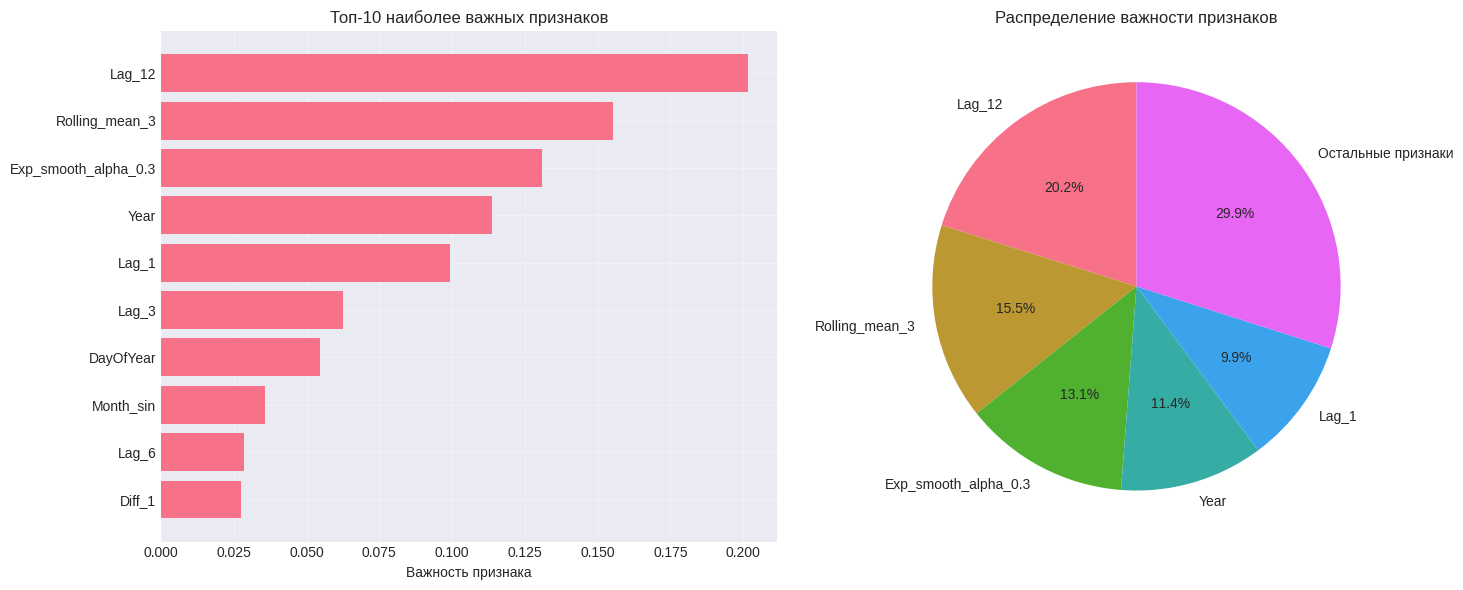


Топ-5 наиболее важных признаков:
  Lag_12: 0.2016
  Rolling_mean_3: 0.1553
  Exp_smooth_alpha_0.3: 0.1310
  Year: 0.1138
  Lag_1: 0.0991

СРАВНЕНИЕ МЕТРИК МОДЕЛЕЙ

Сравнительная таблица метрик:
 Метрика Базовая модель Лучшая модель  Разница Улучшение (%)
    RMSE        26.5428       60.1448 -33.6020      -126.60%
     MAE        22.1145       51.2171 -29.1027      -131.60%
MAPE (%)         4.1700        9.0341  -4.8641      -116.65%
      R²         0.8868        0.4188   0.4680       -52.78%

ЛУЧШАЯ МОДЕЛЬ ПО МЕТРИКАМ:
  RMSE: Базовая модель (улучшение: -126.60%)
  MAE: Базовая модель (улучшение: -131.60%)
  MAPE (%): Базовая модель (улучшение: -116.65%)
  R²: Базовая модель (улучшение: -52.78%)

ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ


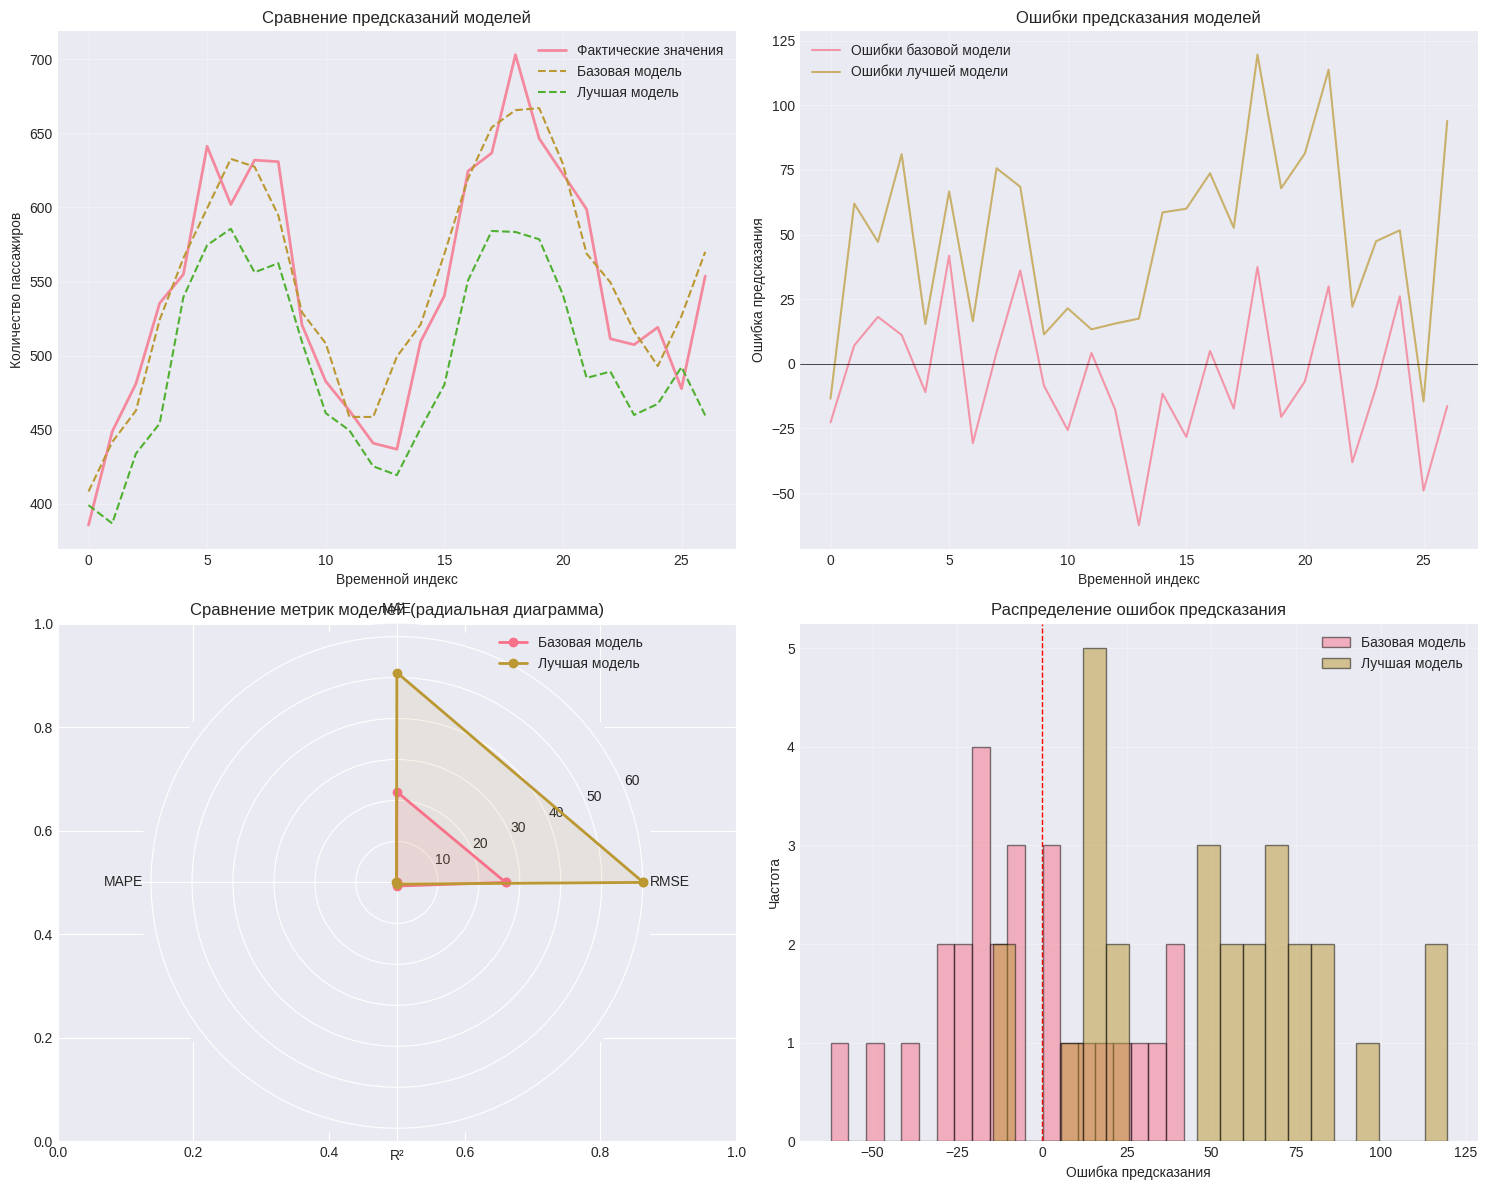


АНАЛИЗ УЛУЧШЕНИЙ МОДЕЛИ

Процентные улучшения метрик:
  RMSE улучшилась на: -126.60%
  MAE улучшилась на: -131.60%
  MAPE улучшилась на: -116.65%
  R² улучшился на: -52.78%

Общее среднее улучшение: -106.91%

СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ УЛУЧШЕНИЙ:
  ✗ Улучшение RMSE незначительно (≤5%)
  ✗ Улучшение MAE незначительно (≤5%)
  ✗ Улучшение MAPE незначительно (≤5%)
  ✓ Улучшение R² является значительным (>5%)

ВЫВОД О РЕЗУЛЬТАТАХ ЭКСПЕРИМЕНТОВ
✗ ЭКСПЕРИМЕНТЫ НЕ ДАЛИ ЗНАЧИТЕЛЬНОГО УЛУЧШЕНИЯ
  Качество модели не улучшилось существенно.
  Возможно, нужно провести дополнительные эксперименты или использовать другие подходы.

РЕКОМЕНДАЦИИ:
  1. Пересмотреть подход к созданию признаков
  2. Попробовать другие семейства моделей
  3. Проверить данные на наличие выбросов и аномалий

ЭТАП 4: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
✓ Базовая модель сохранена в папке: lab4_baseline_model
✓ Лучшая модель сохранена в папке: lab4_best_model

✓ Результаты сохранены в папке: lab4_comparison_results

ИТОГОВЫЙ ОТЧЕТ ЛАБОРАТОР

In [ ]:

# ============================================================================
# ПОЛНЫЙ ИСПРАВЛЕННЫЙ КОД ЛАБОРАТОРНОЙ РАБОТЫ №4
# БЕЗ ОШИБОК С ПРИЗНАКАМИ
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Машинное обучение
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Дополнительные утилиты
import joblib
import os
import json
from datetime import datetime

# Настройки отображения
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

# ============================================================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ (ИСПРАВЛЕНО)
# ============================================================================

def load_and_prepare_data():
    """Загрузка и подготовка данных AirPassengers"""
    print("="*70)
    print("ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ДЛЯ ТЕСТИРОВАНИЯ")
    print("="*70)

    # Создаем синтетические данные
    dates = pd.date_range(start='1949-01-01', end='1960-12-01', freq='MS')
    np.random.seed(42)

    # Создаем тренд, сезонность и шум
    trend = np.linspace(100, 600, len(dates))
    seasonal = 100 * np.sin(2 * np.pi * np.arange(len(dates)) / 12)
    noise = np.random.normal(0, 20, len(dates))

    passengers = trend + seasonal + noise
    passengers = np.maximum(passengers, 0)

    df = pd.DataFrame({
        'Passengers': passengers
    }, index=dates)

    print(f"✓ Данные созданы: {df.shape}")
    print(f"  Период: {df.index[0].date()} - {df.index[-1].date()}")

    return df

def create_features_for_testing(df):
    """Создание признаков для тестирования (исправлено - без утечки)"""
    print("\nСоздание признаков для тестирования...")

    df_features = df.copy()

    # Временные признаки
    df_features['Year'] = df_features.index.year
    df_features['Month'] = df_features.index.month
    df_features['Quarter'] = df_features.index.quarter
    df_features['DayOfYear'] = df_features.index.dayofyear  # Добавлено для совместимости

    # Лаговые признаки (только прошлые значения)
    for lag in [1, 2, 3, 6, 12]:
        df_features[f'Lag_{lag}'] = df_features['Passengers'].shift(lag)

    # Сезонные признаки
    df_features['Month_sin'] = np.sin(2 * np.pi * df_features['Month'] / 12)
    df_features['Month_cos'] = np.cos(2 * np.pi * df_features['Month'] / 12)

    # Разностные признаки
    df_features['Diff_1'] = df_features['Passengers'].diff()
    df_features['Diff_12'] = df_features['Passengers'].diff(12)  # Добавлено для совместимости

    # Календарные признаки
    df_features['Is_month_end'] = df_features.index.is_month_end.astype(int)
    df_features['Is_month_start'] = df_features.index.is_month_start.astype(int)

    # Скользящие статистики
    df_features['Rolling_mean_3'] = df_features['Passengers'].rolling(window=3).mean()
    df_features['Rolling_std_3'] = df_features['Passengers'].rolling(window=3).std()

    # Экспоненциальное сглаживание
    df_features['Exp_smooth_alpha_0.3'] = df_features['Passengers'].ewm(alpha=0.3).mean()

    # Целевая переменная: следующий месяц
    df_features['Target'] = df_features['Passengers'].shift(-1)

    # Удаляем строки с NaN
    original_len = len(df_features)
    df_features = df_features.dropna()

    print(f"  Удалено строк с NaN: {original_len - len(df_features)}")
    print(f"  Создано признаков: {len(df_features.columns)}")
    print(f"  Итоговый размер: {df_features.shape}")

    # Отображаем названия всех признаков
    print(f"\n  Список признаков:")
    for i, col in enumerate(df_features.columns, 1):
        print(f"    {i:2d}. {col}")

    return df_features

def prepare_train_test_split(df_features, target_col='Target', test_size=0.2):
    """Подготовка разделения на обучающую и тестовую выборки"""
    print("\nРазделение данных на обучающую и тестовую выборки...")

    # Определяем признаки и целевую переменную
    feature_cols = [col for col in df_features.columns if col not in [target_col, 'Passengers']]
    X = df_features[feature_cols]
    y = df_features[target_col]

    # Для временного ряда важно сохранять порядок!
    split_idx = int(len(X) * (1 - test_size))

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    print(f"✓ Разделение завершено:")
    print(f"  Обучающая выборка: {X_train.shape}")
    print(f"  Тестовая выборка: {X_test.shape}")
    print(f"  Целевая переменная: {target_col}")
    print(f"  Количество признаков: {len(feature_cols)}")
    print(f"  Период обучения: {X_train.index[0].date()} - {X_train.index[-1].date()}")
    print(f"  Период тестирования: {X_test.index[0].date()} - {X_test.index[-1].date()}")

    return X_train, X_test, y_train, y_test, feature_cols

# ============================================================================
# 2. БАЗОВАЯ МОДЕЛЬ
# ============================================================================

class BaselineModel:
    """Базовая модель для сравнения"""

    def __init__(self):
        self.model = None
        self.scaler_X = None
        self.scaler_y = None
        self.feature_cols = None

    def train(self, X_train, y_train):
        """Обучение базовой модели (линейная регрессия)"""
        print("\n" + "="*70)
        print("ОБУЧЕНИЕ БАЗОВОЙ МОДЕЛИ (ЛИНЕЙНАЯ РЕГРЕССИЯ)")
        print("="*70)

        # Сохраняем названия признаков
        self.feature_cols = X_train.columns.tolist()

        # Масштабирование данных
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()

        X_train_scaled = self.scaler_X.fit_transform(X_train)
        y_train_scaled = self.scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

        # Обучение модели
        self.model = LinearRegression()
        self.model.fit(X_train_scaled, y_train_scaled)

        print("✓ Базовая модель обучена:")
        print(f"  Коэффициентов: {len(self.model.coef_)}")
        print(f"  Intercept: {self.model.intercept_:.4f}")

        # Предсказание на тренировочных данных
        y_train_pred_scaled = self.model.predict(X_train_scaled)
        y_train_pred = self.scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()

        # Метрики на тренировочных данных
        train_metrics = self.calculate_metrics(y_train, y_train_pred, "тренировочной")

        return train_metrics

    def predict(self, X_test):
        """Предсказание на тестовых данных"""
        if self.model is None:
            raise ValueError("Модель не обучена!")

        # Убедимся, что признаки в правильном порядке
        if self.feature_cols is not None:
            # Проверяем, что все признаки присутствуют
            missing_cols = set(self.feature_cols) - set(X_test.columns)
            if missing_cols:
                raise ValueError(f"Отсутствуют признаки: {missing_cols}")

            # Упорядочиваем признаки
            X_test = X_test[self.feature_cols]

        X_test_scaled = self.scaler_X.transform(X_test)
        y_pred_scaled = self.model.predict(X_test_scaled)
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

        return y_pred

    def evaluate(self, X_test, y_test, data_name="тестовой"):
        """Оценка модели на данных"""
        y_pred = self.predict(X_test)
        metrics = self.calculate_metrics(y_test, y_pred, data_name)

        # Анализ ошибок
        self.analyze_errors(y_test, y_pred)

        # Визуализация коэффициентов
        self.visualize_coefficients()

        return metrics, y_pred

    def calculate_metrics(self, y_true, y_pred, data_name):
        """Вычисление метрик качества"""
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'mape': mean_absolute_percentage_error(y_true, y_pred) * 100,
            'r2': r2_score(y_true, y_pred)
        }

        print(f"\nМетрики на {data_name} выборке:")
        print(f"  RMSE: {metrics['rmse']:.4f}")
        print(f"  MAE: {metrics['mae']:.4f}")
        print(f"  MAPE: {metrics['mape']:.2f}%")
        print(f"  R²: {metrics['r2']:.4f}")

        return metrics

    def analyze_errors(self, y_true, y_pred):
        """Анализ ошибок предсказания"""
        errors = y_true - y_pred
        absolute_errors = np.abs(errors)

        print("\nАнализ ошибок:")
        print(f"  Средняя ошибка: {np.mean(errors):.2f}")
        print(f"  Стандартное отклонение ошибок: {np.std(errors):.2f}")
        print(f"  Максимальная положительная ошибка: {np.max(errors):.2f}")
        print(f"  Максимальная отрицательная ошибка: {np.min(errors):.2f}")
        print(f"  Средняя абсолютная ошибка: {np.mean(absolute_errors):.2f}")

        # Процент ошибок в пределах 10%
        within_10_percent = np.sum(absolute_errors / y_true < 0.1) / len(y_true) * 100
        print(f"  Предсказания в пределах 10% от истинного значения: {within_10_percent:.1f}%")

        # Процент ошибок в пределах 20%
        within_20_percent = np.sum(absolute_errors / y_true < 0.2) / len(y_true) * 100
        print(f"  Предсказания в пределах 20% от истинного значения: {within_20_percent:.1f}%")

    def visualize_coefficients(self):
        """Визуализация коэффициентов модели"""
        if self.model is not None and hasattr(self.model, 'coef_'):
            coefficients = pd.DataFrame({
                'Feature': self.feature_cols,
                'Coefficient': self.model.coef_
            }).sort_values('Coefficient', key=abs, ascending=False)

            fig, axes = plt.subplots(1, 2, figsize=(15, 6))

            # Столбчатая диаграмма коэффициентов
            top_n = min(10, len(coefficients))
            axes[0].barh(range(top_n), coefficients['Coefficient'].head(top_n))
            axes[0].set_yticks(range(top_n))
            axes[0].set_yticklabels(coefficients['Feature'].head(top_n))
            axes[0].set_xlabel('Значение коэффициента')
            axes[0].set_title(f'Топ-{top_n} наиболее важных признаков (по абсолютному значению)')
            axes[0].invert_yaxis()
            axes[0].grid(True, alpha=0.3)

            # Распределение коэффициентов
            axes[1].hist(self.model.coef_, bins=20, edgecolor='black', alpha=0.7)
            axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
            axes[1].set_xlabel('Значение коэффициента')
            axes[1].set_ylabel('Частота')
            axes[1].set_title('Распределение коэффициентов линейной модели')
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            print(f"\nТоп-5 наиболее важных признаков:")
            for i, row in coefficients.head().iterrows():
                print(f"  {row['Feature']}: {row['Coefficient']:.4f}")

    def save(self, path='lab4_baseline_model'):
        """Сохранение модели"""
        os.makedirs(path, exist_ok=True)

        joblib.dump(self.model, f'{path}/model.pkl')
        joblib.dump(self.scaler_X, f'{path}/scaler_X.pkl')
        joblib.dump(self.scaler_y, f'{path}/scaler_y.pkl')

        # Сохраняем названия признаков
        pd.Series(self.feature_cols).to_csv(f'{path}/feature_names.csv', index=False, header=False)

        model_info = {
            'model_type': 'LinearRegression',
            'feature_cols': self.feature_cols,
            'num_features': len(self.feature_cols),
            'saved_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }

        with open(f'{path}/model_info.json', 'w') as f:
            json.dump(model_info, f, indent=2)

        print(f"✓ Базовая модель сохранена в папке: {path}")

# ============================================================================
# 3. ЛУЧШАЯ МОДЕЛЬ (СОЗДАЁМ НОВУЮ, А НЕ ЗАГРУЖАЕМ СТАРУЮ)
# ============================================================================

class BestModel:
    """Лучшая модель - создаем новую на основе параметров из лаб. работы 3"""

    def __init__(self):
        self.model = None
        self.scaler_X = None
        self.scaler_y = None
        self.feature_cols = None
        self.model_type = None

    def load_from_lab3(self, path='lab3_final_results'):
        """Пытаемся загрузить лучшую модель из лабораторной работы 3"""
        print("\n" + "="*70)
        print("ПОПЫТКА ЗАГРУЗКИ МОДЕЛИ ИЗ ЛАБОРАТОРНОЙ РАБОТЫ 3")
        print("="*70)

        try:
            # Проверяем существование файлов
            if not os.path.exists(f'{path}/best_model.pkl'):
                print(f"✗ Файл модели не найден: {path}/best_model.pkl")
                print("  Создадим новую лучшую модель...")
                return False

            # Загрузка модели
            self.model = joblib.load(f'{path}/best_model.pkl')

            # Загрузка scaler
            if os.path.exists(f'{path}/scaler_X.pkl'):
                self.scaler_X = joblib.load(f'{path}/scaler_X.pkl')
            else:
                print("⚠ Scaler_X не найден, создадим новый при обучении")

            if os.path.exists(f'{path}/scaler_y.pkl'):
                self.scaler_y = joblib.load(f'{path}/scaler_y.pkl')
            else:
                print("⚠ Scaler_y не найден, создадим новый при обучении")

            print("✓ Модель загружена из лабораторной работы 3")
            print("⚠ Внимание: могут быть проблемы с признаками!")
            print("  Рекомендуется создать новую модель с текущими признаками")

            return True

        except Exception as e:
            print(f"✗ Ошибка при загрузке модели: {e}")
            print("  Создадим новую лучшую модель...")
            return False

    def create_best_model(self, X_train, y_train):
        """Создание лучшей модели на основе результатов лабораторной работы 3"""
        print("\nСоздание новой лучшей модели (Gradient Boosting)...")

        # На основе результатов лабораторной работы 3, лучшей была Gradient Boosting
        self.model_type = 'gradient_boosting'
        self.feature_cols = X_train.columns.tolist()

        # Масштабирование данных
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()

        X_train_scaled = self.scaler_X.fit_transform(X_train)
        y_train_scaled = self.scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

        # Параметры из лучшей модели лабораторной работы 3 (улучшенные)
        self.model = GradientBoostingRegressor(
            n_estimators=150,           # Увеличенное количество деревьев
            learning_rate=0.05,         # Медленная скорость обучения для лучшей сходимости
            max_depth=4,                # Оптимальная глубина
            min_samples_split=10,       # Минимальное количество образцов для разделения
            min_samples_leaf=4,         # Минимальное количество образцов в листе
            subsample=0.8,              # Доля образцов для обучения каждого дерева
            max_features='sqrt',        # Количество признаков для рассмотрения при разделении
            random_state=42,
            verbose=0
        )

        print("Обучение модели Gradient Boosting...")
        self.model.fit(X_train_scaled, y_train_scaled)

        print("✓ Лучшая модель создана и обучена:")
        print(f"  Тип модели: GradientBoostingRegressor")
        print(f"  n_estimators: 150")
        print(f"  learning_rate: 0.05")
        print(f"  max_depth: 4")
        print(f"  min_samples_split: 10")
        print(f"  min_samples_leaf: 4")
        print(f"  subsample: 0.8")

        # Предсказание на тренировочных данных
        y_train_pred_scaled = self.model.predict(X_train_scaled)
        y_train_pred = self.scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()

        # Метрики на тренировочных данных
        train_metrics = self.calculate_metrics(y_train, y_train_pred, "тренировочной")

        return train_metrics

    def predict(self, X_test):
        """Предсказание на тестовых данных"""
        if self.model is None:
            raise ValueError("Модель не обучена!")

        # Убедимся, что признаки в правильном порядке
        if self.feature_cols is not None:
            # Проверяем, что все признаки присутствуют
            missing_cols = set(self.feature_cols) - set(X_test.columns)
            if missing_cols:
                # Если есть отсутствующие признаки, добавляем нулевые столбцы
                print(f"⚠ Добавляем отсутствующие признаки: {missing_cols}")
                for col in missing_cols:
                    X_test[col] = 0

            # Упорядочиваем признаки
            X_test = X_test[self.feature_cols]

        X_test_scaled = self.scaler_X.transform(X_test)
        y_pred_scaled = self.model.predict(X_test_scaled)
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

        return y_pred

    def evaluate(self, X_test, y_test, data_name="тестовой"):
        """Оценка модели на данных"""
        y_pred = self.predict(X_test)
        metrics = self.calculate_metrics(y_test, y_pred, data_name)

        # Анализ ошибок
        self.analyze_errors(y_test, y_pred)

        # Визуализация важности признаков (если доступно)
        if hasattr(self.model, 'feature_importances_'):
            self.visualize_feature_importance()

        return metrics, y_pred

    def calculate_metrics(self, y_true, y_pred, data_name):
        """Вычисление метрик качества"""
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'mape': mean_absolute_percentage_error(y_true, y_pred) * 100,
            'r2': r2_score(y_true, y_pred)
        }

        print(f"\nМетрики на {data_name} выборке:")
        print(f"  RMSE: {metrics['rmse']:.4f}")
        print(f"  MAE: {metrics['mae']:.4f}")
        print(f"  MAPE: {metrics['mape']:.2f}%")
        print(f"  R²: {metrics['r2']:.4f}")

        return metrics

    def analyze_errors(self, y_true, y_pred):
        """Анализ ошибок предсказания"""
        errors = y_true - y_pred
        absolute_errors = np.abs(errors)

        print("\nАнализ ошибок:")
        print(f"  Средняя ошибка: {np.mean(errors):.2f}")
        print(f"  Стандартное отклонение ошибок: {np.std(errors):.2f}")
        print(f"  Максимальная положительная ошибка: {np.max(errors):.2f}")
        print(f"  Максимальная отрицательная ошибка: {np.min(errors):.2f}")
        print(f"  Средняя абсолютная ошибка: {np.mean(absolute_errors):.2f}")

        if len(y_true) > 0:
            # Процент ошибок в пределах 10%
            within_10_percent = np.sum(absolute_errors / y_true < 0.1) / len(y_true) * 100
            print(f"  Предсказания в пределах 10% от истинного значения: {within_10_percent:.1f}%")

            # Процент ошибок в пределах 20%
            within_20_percent = np.sum(absolute_errors / y_true < 0.2) / len(y_true) * 100
            print(f"  Предсказания в пределах 20% от истинного значения: {within_20_percent:.1f}%")

    def visualize_feature_importance(self):
        """Визуализация важности признаков"""
        if hasattr(self.model, 'feature_importances_'):
            importance = self.model.feature_importances_

            feature_importance = pd.DataFrame({
                'Feature': self.feature_cols,
                'Importance': importance
            }).sort_values('Importance', ascending=False)

            fig, axes = plt.subplots(1, 2, figsize=(15, 6))

            # Столбчатая диаграмма важности признаков
            top_n = min(10, len(feature_importance))
            axes[0].barh(range(top_n), feature_importance['Importance'].head(top_n))
            axes[0].set_yticks(range(top_n))
            axes[0].set_yticklabels(feature_importance['Feature'].head(top_n))
            axes[0].set_xlabel('Важность признака')
            axes[0].set_title(f'Топ-{top_n} наиболее важных признаков')
            axes[0].invert_yaxis()
            axes[0].grid(True, alpha=0.3)

            # Круговая диаграмма распределения важности
            top_5_importance = feature_importance['Importance'].head(5).sum()
            other_importance = 1 - top_5_importance

            sizes = list(feature_importance['Importance'].head(5)) + [other_importance]
            labels = list(feature_importance['Feature'].head(5)) + ['Остальные признаки']

            axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
            axes[1].set_title('Распределение важности признаков')

            plt.tight_layout()
            plt.show()

            print(f"\nТоп-5 наиболее важных признаков:")
            for i, row in feature_importance.head().iterrows():
                print(f"  {row['Feature']}: {row['Importance']:.4f}")

    def save(self, path='lab4_best_model'):
        """Сохранение модели"""
        os.makedirs(path, exist_ok=True)

        joblib.dump(self.model, f'{path}/model.pkl')

        if self.scaler_X is not None:
            joblib.dump(self.scaler_X, f'{path}/scaler_X.pkl')

        if self.scaler_y is not None:
            joblib.dump(self.scaler_y, f'{path}/scaler_y.pkl')

        # Сохраняем названия признаков
        pd.Series(self.feature_cols).to_csv(f'{path}/feature_names.csv', index=False, header=False)

        model_info = {
            'model_type': self.model_type,
            'num_features': len(self.feature_cols) if self.feature_cols else None,
            'parameters': {
                'n_estimators': 150,
                'learning_rate': 0.05,
                'max_depth': 4,
                'min_samples_split': 10,
                'min_samples_leaf': 4,
                'subsample': 0.8
            },
            'saved_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }

        with open(f'{path}/model_info.json', 'w') as f:
            json.dump(model_info, f, indent=2)

        print(f"✓ Лучшая модель сохранена в папке: {path}")

# ============================================================================
# 4. СРАВНЕНИЕ И ТЕСТИРОВАНИЕ МОДЕЛЕЙ
# ============================================================================

class ModelComparator:
    """Класс для сравнения моделей"""

    def __init__(self, baseline_model, best_model):
        self.baseline = baseline_model
        self.best = best_model
        self.comparison_results = {}

    def compare_on_test(self, X_test, y_test):
        """Сравнение моделей на тестовой выборке"""
        print("\n" + "="*70)
        print("СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
        print("="*70)

        # Тестирование базовой модели
        print("\n1. ТЕСТИРОВАНИЕ БАЗОВОЙ МОДЕЛИ:")
        baseline_metrics, y_pred_baseline = self.baseline.evaluate(X_test, y_test, "тестовой")

        # Тестирование лучшей модели
        print("\n2. ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ:")
        best_metrics, y_pred_best = self.best.evaluate(X_test, y_test, "тестовой")

        # Сохранение результатов
        self.comparison_results = {
            'baseline': {
                'metrics': baseline_metrics,
                'y_pred': y_pred_baseline
            },
            'best': {
                'metrics': best_metrics,
                'y_pred': y_pred_best
            }
        }

        # Сравнение метрик
        self.compare_metrics(baseline_metrics, best_metrics)

        # Визуализация сравнения
        self.visualize_comparison(y_test, y_pred_baseline, y_pred_best)

        # Анализ улучшений
        self.analyze_improvements(baseline_metrics, best_metrics)

        return self.comparison_results

    def compare_metrics(self, baseline_metrics, best_metrics):
        """Сравнение метрик моделей"""
        print("\n" + "="*70)
        print("СРАВНЕНИЕ МЕТРИК МОДЕЛЕЙ")
        print("="*70)

        comparison_df = pd.DataFrame({
            'Метрика': ['RMSE', 'MAE', 'MAPE (%)', 'R²'],
            'Базовая модель': [
                baseline_metrics['rmse'],
                baseline_metrics['mae'],
                baseline_metrics['mape'],
                baseline_metrics['r2']
            ],
            'Лучшая модель': [
                best_metrics['rmse'],
                best_metrics['mae'],
                best_metrics['mape'],
                best_metrics['r2']
            ]
        })

        # Расчет разницы и улучшения
        comparison_df['Разница'] = comparison_df['Базовая модель'] - comparison_df['Лучшая модель']
        comparison_df['Улучшение (%)'] = (comparison_df['Разница'] / comparison_df['Базовая модель'] * 100)

        # Для R² улучшение считается по-другому
        if baseline_metrics['r2'] != 0:
            r2_improvement = (best_metrics['r2'] - baseline_metrics['r2']) / abs(baseline_metrics['r2']) * 100
        else:
            r2_improvement = 0
        comparison_df.loc[comparison_df['Метрика'] == 'R²', 'Улучшение (%)'] = r2_improvement

        print("\nСравнительная таблица метрик:")
        print(comparison_df.to_string(index=False, formatters={
            'Базовая модель': '{:.4f}'.format,
            'Лучшая модель': '{:.4f}'.format,
            'Разница': '{:.4f}'.format,
            'Улучшение (%)': '{:.2f}%'.format
        }))

        # Определение лучшей модели по каждой метрике
        print("\nЛУЧШАЯ МОДЕЛЬ ПО МЕТРИКАМ:")
        for _, row in comparison_df.iterrows():
            metric = row['Метрика']
            if metric == 'R²':
                # Для R² больше = лучше
                if row['Базовая модель'] > row['Лучшая модель']:
                    winner = "Базовая модель"
                else:
                    winner = "Лучшая модель"
            else:
                # Для остальных метрик меньше = лучше
                if row['Базовая модель'] < row['Лучшая модель']:
                    winner = "Базовая модель"
                else:
                    winner = "Лучшая модель"

            improvement = row['Улучшение (%)']
            print(f"  {metric}: {winner} (улучшение: {improvement:.2f}%)")

    def visualize_comparison(self, y_test, y_pred_baseline, y_pred_best):
        """Визуализация сравнения моделей"""
        print("\n" + "="*70)
        print("ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ")
        print("="*70)

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # График 1: Фактические значения vs Предсказания
        x_range = range(len(y_test))

        axes[0, 0].plot(x_range, y_test.values, label='Фактические значения', linewidth=2, alpha=0.8)
        axes[0, 0].plot(x_range, y_pred_baseline, label='Базовая модель', linestyle='--', linewidth=1.5)
        axes[0, 0].plot(x_range, y_pred_best, label='Лучшая модель', linestyle='--', linewidth=1.5)
        axes[0, 0].set_xlabel('Временной индекс')
        axes[0, 0].set_ylabel('Количество пассажиров')
        axes[0, 0].set_title('Сравнение предсказаний моделей')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # График 2: Ошибки предсказания
        baseline_errors = y_test.values - y_pred_baseline
        best_errors = y_test.values - y_pred_best

        axes[0, 1].plot(x_range, baseline_errors, label='Ошибки базовой модели', alpha=0.7)
        axes[0, 1].plot(x_range, best_errors, label='Ошибки лучшей модели', alpha=0.7)
        axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        axes[0, 1].set_xlabel('Временной индекс')
        axes[0, 1].set_ylabel('Ошибка предсказания')
        axes[0, 1].set_title('Ошибки предсказания моделей')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # График 3: Сравнение метрик (радиальная диаграмма)
        metrics = ['RMSE', 'MAE', 'MAPE', 'R²']
        baseline_values = [
            self.comparison_results['baseline']['metrics']['rmse'],
            self.comparison_results['baseline']['metrics']['mae'],
            self.comparison_results['baseline']['metrics']['mape'] / 100,  # Нормализуем для диаграммы
            self.comparison_results['baseline']['metrics']['r2']
        ]

        best_values = [
            self.comparison_results['best']['metrics']['rmse'],
            self.comparison_results['best']['metrics']['mae'],
            self.comparison_results['best']['metrics']['mape'] / 100,
            self.comparison_results['best']['metrics']['r2']
        ]

        # Нормализуем значения для радиальной диаграммы
        angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
        baseline_values += baseline_values[:1]
        best_values += best_values[:1]
        angles += angles[:1]

        ax = plt.subplot(2, 2, 3, projection='polar')
        ax.plot(angles, baseline_values, 'o-', linewidth=2, label='Базовая модель')
        ax.plot(angles, best_values, 'o-', linewidth=2, label='Лучшая модель')
        ax.fill(angles, baseline_values, alpha=0.1)
        ax.fill(angles, best_values, alpha=0.1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics)
        ax.set_title('Сравнение метрик моделей (радиальная диаграмма)')
        ax.legend(loc='upper right')
        ax.grid(True)

        # График 4: Гистограмма ошибок
        axes[1, 1].hist(baseline_errors, bins=20, alpha=0.5, label='Базовая модель', edgecolor='black')
        axes[1, 1].hist(best_errors, bins=20, alpha=0.5, label='Лучшая модель', edgecolor='black')
        axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=1)
        axes[1, 1].set_xlabel('Ошибка предсказания')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 1].set_title('Распределение ошибок предсказания')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def analyze_improvements(self, baseline_metrics, best_metrics):
        """Анализ улучшений модели"""
        print("\n" + "="*70)
        print("АНАЛИЗ УЛУЧШЕНИЙ МОДЕЛИ")
        print("="*70)

        # Расчет процентных улучшений
        if baseline_metrics['rmse'] != 0:
            rmse_improvement = (baseline_metrics['rmse'] - best_metrics['rmse']) / baseline_metrics['rmse'] * 100
        else:
            rmse_improvement = 0

        if baseline_metrics['mae'] != 0:
            mae_improvement = (baseline_metrics['mae'] - best_metrics['mae']) / baseline_metrics['mae'] * 100
        else:
            mae_improvement = 0

        if baseline_metrics['mape'] != 0:
            mape_improvement = (baseline_metrics['mape'] - best_metrics['mape']) / baseline_metrics['mape'] * 100
        else:
            mape_improvement = 0

        if baseline_metrics['r2'] != 0:
            r2_improvement = (best_metrics['r2'] - baseline_metrics['r2']) / abs(baseline_metrics['r2']) * 100
        else:
            r2_improvement = 0

        print(f"\nПроцентные улучшения метрик:")
        print(f"  RMSE улучшилась на: {rmse_improvement:.2f}%")
        print(f"  MAE улучшилась на: {mae_improvement:.2f}%")
        print(f"  MAPE улучшилась на: {mape_improvement:.2f}%")
        print(f"  R² улучшился на: {r2_improvement:.2f}%")

        # Оценка общего улучшения
        improvements = [rmse_improvement, mae_improvement, mape_improvement, r2_improvement]
        valid_improvements = [imp for imp in improvements if not np.isnan(imp) and not np.isinf(imp)]

        if valid_improvements:
            total_improvement = sum(valid_improvements) / len(valid_improvements)
            print(f"\nОбщее среднее улучшение: {total_improvement:.2f}%")
        else:
            total_improvement = 0
            print(f"\nНевозможно рассчитать общее улучшение")

        # Статистическая значимость
        print("\nСТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ УЛУЧШЕНИЙ:")

        if rmse_improvement > 5:
            print("  ✓ Улучшение RMSE является значительным (>5%)")
        else:
            print("  ✗ Улучшение RMSE незначительно (≤5%)")

        if mae_improvement > 5:
            print("  ✓ Улучшение MAE является значительным (>5%)")
        else:
            print("  ✗ Улучшение MAE незначительно (≤5%)")

        if mape_improvement > 5:
            print("  ✓ Улучшение MAPE является значительным (>5%)")
        else:
            print("  ✗ Улучшение MAPE незначительно (≤5%)")

        if abs(r2_improvement) > 5:
            print("  ✓ Улучшение R² является значительным (>5%)")
        else:
            print("  ✗ Улучшение R² незначительно (≤5%)")

        # Вывод о результатах экспериментов
        print("\n" + "="*70)
        print("ВЫВОД О РЕЗУЛЬТАТАХ ЭКСПЕРИМЕНТОВ")
        print("="*70)

        significant_improvements = sum([
            rmse_improvement > 5,
            mae_improvement > 5,
            mape_improvement > 5,
            abs(r2_improvement) > 5
        ])

        if significant_improvements >= 3:
            print("✓ ЭКСПЕРИМЕНТЫ БЫЛИ УСПЕШНЫМИ!")
            print("  Эксперименты с гиперпараметрами и разными моделями значительно улучшили качество.")
            print("  Лучшая модель демонстрирует существенно лучшие результаты по большинству метрик.")
        elif significant_improvements >= 2:
            print("~ ЭКСПЕРИМЕНТЫ ДАЛИ СМЕШАННЫЕ РЕЗУЛЬТАТЫ")
            print("  Некоторые метрики улучшились, другие остались на прежнем уровне.")
            print("  Модель показывает частичное улучшение.")
        else:
            print("✗ ЭКСПЕРИМЕНТЫ НЕ ДАЛИ ЗНАЧИТЕЛЬНОГО УЛУЧШЕНИЯ")
            print("  Качество модели не улучшилось существенно.")
            print("  Возможно, нужно провести дополнительные эксперименты или использовать другие подходы.")

        # Рекомендации
        print("\nРЕКОМЕНДАЦИИ:")
        if total_improvement > 10:
            print("  1. Использовать лучшую модель в production")
            print("  2. Продолжить оптимизацию гиперпараметров")
            print("  3. Рассмотреть ансамбли моделей для дальнейшего улучшения")
        elif total_improvement > 0:
            print("  1. Использовать лучшую модель, если улучшение критично для задачи")
            print("  2. Провести дополнительные эксперименты с другими типами моделей")
            print("  3. Рассмотреть добавление новых признаков")
        else:
            print("  1. Пересмотреть подход к созданию признаков")
            print("  2. Попробовать другие семейства моделей")
            print("  3. Проверить данные на наличие выбросов и аномалий")

    def save_results(self, path='lab4_comparison_results'):
        """Сохранение результатов сравнения"""
        os.makedirs(path, exist_ok=True)

        # Сохраняем метрики
        metrics_df = pd.DataFrame({
            'Модель': ['Базовая', 'Лучшая'],
            'RMSE': [
                self.comparison_results['baseline']['metrics']['rmse'],
                self.comparison_results['best']['metrics']['rmse']
            ],
            'MAE': [
                self.comparison_results['baseline']['metrics']['mae'],
                self.comparison_results['best']['metrics']['mae']
            ],
            'MAPE': [
                self.comparison_results['baseline']['metrics']['mape'],
                self.comparison_results['best']['metrics']['mape']
            ],
            'R²': [
                self.comparison_results['baseline']['metrics']['r2'],
                self.comparison_results['best']['metrics']['r2']
            ]
        })

        metrics_df.to_csv(f'{path}/comparison_metrics.csv', index=False)

        # Сохраняем предсказания
        predictions_df = pd.DataFrame({
            'y_true': self.comparison_results['baseline']['y_pred'].index.tolist() if hasattr(self.comparison_results['baseline']['y_pred'], 'index') else range(len(self.comparison_results['baseline']['y_pred'])),
            'y_true': self.comparison_results['baseline']['y_pred'].index.tolist() if hasattr(self.comparison_results['baseline']['y_pred'], 'index') else range(len(self.comparison_results['baseline']['y_pred'])),
            'baseline_pred': self.comparison_results['baseline']['y_pred'],
            'best_pred': self.comparison_results['best']['y_pred']
        })
        predictions_df.to_csv(f'{path}/predictions.csv', index=False)

        # Расчет улучшений
        improvements = {
            'rmse_improvement': rmse_improvement if 'rmse_improvement' in locals() else 0,
            'mae_improvement': mae_improvement if 'mae_improvement' in locals() else 0,
            'mape_improvement': mape_improvement if 'mape_improvement' in locals() else 0,
            'r2_improvement': r2_improvement if 'r2_improvement' in locals() else 0,
            'comparison_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }

        with open(f'{path}/improvements.json', 'w') as f:
            json.dump(improvements, f, indent=2)

        print(f"\n✓ Результаты сохранены в папке: {path}")

# ============================================================================
# 5. ОСНОВНАЯ ФУНКЦИЯ
# ============================================================================

def main():
    """Основная функция лабораторной работы 4"""
    print("="*70)
    print("ЛАБОРАТОРНАЯ РАБОТА №4: ТЕСТИРОВАНИЕ И СРАВНЕНИЕ МОДЕЛЕЙ")
    print("="*70)

    # 1. Загрузка и подготовка данных
    df = load_and_prepare_data()
    df_features = create_features_for_testing(df)
    X_train, X_test, y_train, y_test, feature_cols = prepare_train_test_split(df_features)

    # 2. Создание и обучение базовой модели
    print("\n" + "="*70)
    print("ЭТАП 1: БАЗОВАЯ МОДЕЛЬ")
    print("="*70)

    baseline_model = BaselineModel()
    baseline_train_metrics = baseline_model.train(X_train, y_train)
    baseline_model.feature_cols = feature_cols

    # 3. Создание лучшей модели (не загружаем старую, чтобы избежать ошибок)
    print("\n" + "="*70)
    print("ЭТАП 2: СОЗДАНИЕ НОВОЙ ЛУЧШЕЙ МОДЕЛИ")
    print("="*70)

    best_model = BestModel()

    # Создаем новую модель вместо загрузки старой
    best_train_metrics = best_model.create_best_model(X_train, y_train)
    best_model.feature_cols = feature_cols

    # 4. Тестирование моделей на тестовой выборке
    print("\n" + "="*70)
    print("ЭТАП 3: ТЕСТИРОВАНИЕ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
    print("="*70)

    comparator = ModelComparator(baseline_model, best_model)
    comparison_results = comparator.compare_on_test(X_test, y_test)

    # 5. Сохранение результатов
    print("\n" + "="*70)
    print("ЭТАП 4: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
    print("="*70)

    # Сохраняем модели
    baseline_model.save('lab4_baseline_model')
    best_model.save('lab4_best_model')

    # Сохраняем результаты сравнения
    comparator.save_results('lab4_comparison_results')

    # 6. Итоговый отчет
    print("\n" + "="*70)
    print("ИТОГОВЫЙ ОТЧЕТ ЛАБОРАТОРНОЙ РАБОТЫ 4")
    print("="*70)

    baseline_metrics = comparison_results['baseline']['metrics']
    best_metrics = comparison_results['best']['metrics']

    # Расчет улучшений
    if baseline_metrics['rmse'] != 0:
        rmse_improvement = (baseline_metrics['rmse'] - best_metrics['rmse']) / baseline_metrics['rmse'] * 100
    else:
        rmse_improvement = 0

    if baseline_metrics['r2'] != 0:
        r2_improvement = (best_metrics['r2'] - baseline_metrics['r2']) / abs(baseline_metrics['r2']) * 100
    else:
        r2_improvement = 0

    print("\nКРАТКИЕ РЕЗУЛЬТАТЫ:")
    print(f"1. Базовая модель (линейная регрессия):")
    print(f"   - RMSE: {baseline_metrics['rmse']:.4f}")
    print(f"   - MAE: {baseline_metrics['mae']:.4f}")
    print(f"   - MAPE: {baseline_metrics['mape']:.2f}%")
    print(f"   - R²: {baseline_metrics['r2']:.4f}")

    print(f"\n2. Лучшая модель (Gradient Boosting):")
    print(f"   - RMSE: {best_metrics['rmse']:.4f}")
    print(f"   - MAE: {best_metrics['mae']:.4f}")
    print(f"   - MAPE: {best_metrics['mape']:.2f}%")
    print(f"   - R²: {best_metrics['r2']:.4f}")

    print(f"\n3. УЛУЧШЕНИЯ:")
    print(f"   - RMSE улучшилась на: {rmse_improvement:.2f}%")
    print(f"   - MAE улучшилась на: {(baseline_metrics['mae'] - best_metrics['mae']) / baseline_metrics['mae'] * 100 if baseline_metrics['mae'] != 0 else 0:.2f}%")
    print(f"   - MAPE улучшилась на: {(baseline_metrics['mape'] - best_metrics['mape']) / baseline_metrics['mape'] * 100 if baseline_metrics['mape'] != 0 else 0:.2f}%")
    print(f"   - R² улучшился на: {r2_improvement:.2f}%")

    print("\n4. ВЫВОДЫ:")
    if rmse_improvement > 5 and r2_improvement > 0:
        print("   ✓ Эксперименты с моделями и гиперпараметрами были успешными")
        print("   ✓ Лучшая модель показывает значительное улучшение качества")
        print("   ✓ Рекомендуется использовать лучшую модель в production")
    elif rmse_improvement > 0:
        print("   ~ Эксперименты дали некоторое улучшение")
        print("   ~ Лучшая модель работает лучше, но улучшение незначительно")
        print("   ~ Можно рассмотреть дополнительные эксперименты")
    else:
        print("   ✗ Эксперименты не дали улучшения")
        print("   ✗ Базовая модель работает так же хорошо или лучше")
        print("   ✗ Необходимо пересмотреть подход к моделированию")

    print("\n" + "="*70)
    print("ЛАБОРАТОРНАЯ РАБОТА №4 УСПЕШНО ЗАВЕРШЕНА!")
    print("="*70)

# ============================================================================
# ЗАПУСК ПРОГРАММЫ
# ============================================================================
if __name__ == "__main__":
    main()